###Creating a hamiltonian creation function:
The code cell directly below creates a Hamiltoncreation function which returns the hamiltonian for a SSH model of a chain of particles with paramaters including: chain length with N cell numbers, the hopping amplitude of intracell-v, and the intercell hopping amplitude-w.  

TODO: ADD sliders to winding numbers, clean up localization lenght and winding number presentation, write README.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
sum1 = 0 
sum2 = 0
n = 4
v=1
w=2
def delta_kronecker(i,j):
    if i==j:
        return 1
    else:
        return 0
def Hamiltoniancreattion(n,v,w): 
    H = np.zeros((2*n, 2*n))
    for i in range(2*n):
        for j in range(2*n):
            p1=0
            p2=0
            for k in range(1,2*n,2):
                p1 += delta_kronecker(i+1,k+1)*delta_kronecker(j+1,k)+delta_kronecker(j+1,k+1)*delta_kronecker(i+1,k) 
            for k in range(1,2*(n-1),2):
                p2 += delta_kronecker(i+1,k+2)*delta_kronecker(j+1,k+1)+delta_kronecker(j+1,k+2)*delta_kronecker(i+1,k+1)
            H[i][j]= v*p1+w*p2
    return H
print(Hamiltoniancreattion(n,v,w))

[[0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 2. 0. 0. 0. 0. 0.]
 [0. 2. 0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 2. 0. 0. 0.]
 [0. 0. 0. 2. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0. 2. 0.]
 [0. 0. 0. 0. 0. 2. 0. 1.]
 [0. 0. 0. 0. 0. 0. 1. 0.]]


###Plotting the energy spectrum of a SSH model: 8 different energy eigenvalues corresponding to 4 cells are ploted in the y axis and changes as function of v, the intracell hopping amplitude, from values from 0 to 2 and with fixed intercell hopping value w. 

(40, 8, 8)


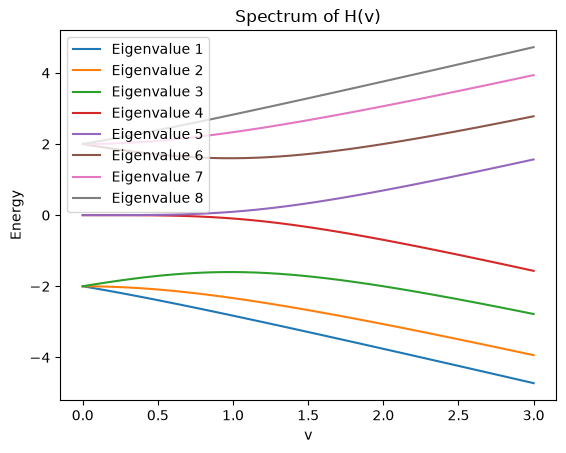

In [2]:
vvals = np.linspace(0,3,40)
Hmaster= np.zeros((40, 2*n, 2*n))
for k in range(40):
    Hmaster[k]= Hamiltoniancreattion(n,vvals[k],w)
print(np.shape(Hmaster))
Hmastereigvals= []
Hmastereigvecs= []
for k in range(40):
    Hk=Hmaster[k]
    eigvals, eigvecs = np.linalg.eigh(Hk)
    Hmastereigvals.append(eigvals)
    Hmastereigvecs.append(eigvecs)
Hmastereigvals= np.array(Hmastereigvals)
Hmastereigvecs= np.array(Hmastereigvecs)

for k in range(8):
    plt.plot(vvals,Hmastereigvals[:,k], label=f'Eigenvalue {k+1}')
plt.xlabel('v')
plt.ylabel('Energy')
plt.title('Spectrum of H(v)')
plt.legend()
plt.show()
 

###Plotting the probability of zero eigenstate being present in cells for the SSH model as well as calculating the localization length: 10 cells are plotted corresponding to 20 sites. Each site corresponds to a value on the x axis with the corresponding y value being the probabilty the site hosts a zero energy eigenstate. Localization length is calculated by extracting w/v from the eigen vectors and using then using the formula $\xi = \frac{1}{\log{\frac{w}{v}}}$ 

C:\Users\aman1\AppData\Local\Temp\ipykernel_34852\1895183012.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


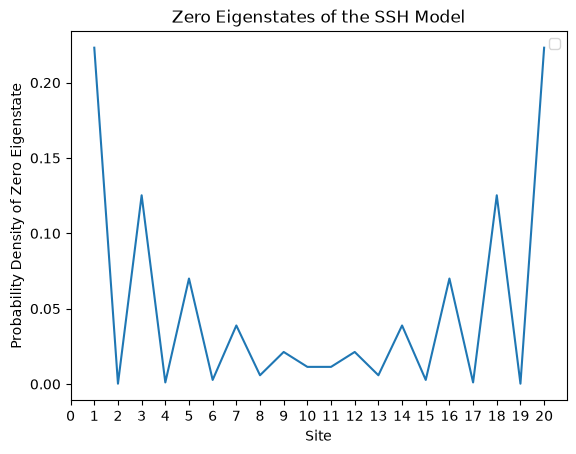

[-6.92236176 -6.69122014 -6.31186563 -5.79302643 -5.14676614 -4.38844159
 -3.53700205 -2.61690734 -1.67138048 -0.09978056  0.09978056  1.67138048
  2.61690734  3.53700205  4.38844159  5.14676614  5.79302643  6.31186563
  6.69122014  6.92236176]
[[-0.0398241  -0.07871883 -0.11576462 -0.1500547   0.18067762 -0.20663793
   0.22655511  0.23729127 -0.22389051 -0.47243472 -0.47243472 -0.22389051
  -0.23729127 -0.22655511 -0.20663793 -0.18067762  0.1500547  -0.11576462
  -0.07871883  0.0398241 ]
 [ 0.09189228  0.17557501  0.24356357  0.28975694 -0.30996848  0.30227283
  -0.26710863 -0.20698976  0.12473541  0.01571327 -0.01571327 -0.12473541
  -0.20698976 -0.26710863 -0.30227283 -0.30996848  0.28975694 -0.24356357
  -0.17557501  0.09189228]
 [-0.12915982 -0.23466364 -0.29751166 -0.30710138  0.26332561 -0.17664822
   0.06627461 -0.0425502   0.1157978   0.35393407  0.35393407  0.1157978
   0.0425502  -0.06627461 -0.17664822 -0.26332561  0.30710138 -0.29751166
  -0.23466364  0.12915982]
 [ 0.1755

In [ ]:
v = 3
w = 4
Hnew = Hamiltoniancreattion(10,v,w)
eigvalsnew, eigvecsnew = np.linalg.eigh(Hnew)
plt.plot(np.linspace(1,20,20),eigvecsnew[:,10]*eigvecsnew[:,10])
plt.xlabel('Site')
plt.ylabel('Probability Density of Zero Eigenstate')
plt.xticks(np.arange(0, 21, 1))
plt.title('Zero Eigenstates of the SSH Model')
plt.legend()
plt.show()
print(eigvalsnew)
print(eigvecsnew)
print("Localization Length:",1/np.log(-1*eigvecsnew[0,10]/eigvecsnew[2,10]))


###Graphing and calculating the winding number for a SSH model: The x and y values are paramaterized functions of the winding number k ranging from 0 to 2 pi. The paramaterizations are based on writting the hamiltonian for the SSH model in terms of pauli matrixies resulting in the following paramaterizations: $x = v+w\cos{k}$, $y = w\sin{k}$.
The winding number is numerically calculated from the following formula: $v = \frac{1}{2\pi i} \int_{-\pi}^{\pi} dk \frac{d}{dk} \log h(k)$

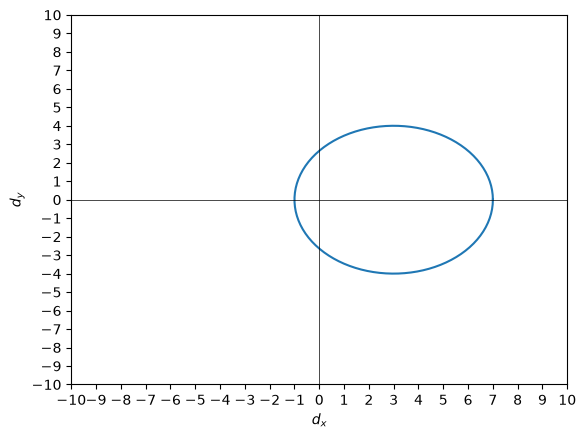

Winding number: (-1.0 + 0.0j)
Localization Length: 3.4627366702602407


In [ ]:
import mpmath as mp 
v = float(input("Enter v- the ampplitude for intracell hopping: "))
w = float(input("Enter w- the ampplitude for intercell hopping: "))
k = np.linspace(0, 2*np.pi, 100)
plt.plot(v+w*np.cos(k),w*np.sin(k))
plt.xlabel('$d_{x}$')
plt.ylabel('$d_{y}$')
plt.xticks(np.arange(-10, 11, 1))
plt.yticks(np.arange(-10, 11, 1))
plt.axhline(0, color='black', lw=0.5)
plt.axvline(0, color='black', lw=0.5)
plt.show()
diffel= lambda k:mp.log(v+w*mp.exp(-1*mp.j*k))
integral = (mp.quad(lambda k: mp.diff(diffel, k), [-mp.pi, mp.pi]))/(2*mp.pi*mp.j)
print("Winding number:", mp.nint(integral))
